# Solver Benchmark — 2026-04-15 · ball_rollers_8

Matrices from `spheres_ball_rollers_small_test` (6 mesh sizes: 7034, 9996, 30116, 50025, 70647, 91089).

- `ball_rollers_8` — 8-way parallel (`OMP_NUM_THREADS=8` for OMP solvers, `mpirun -np 8` for MPI solvers)

**Solvers:** AMGCL (OMP iterative), Eigen::PardisoLDLT (OMP direct), Hypre_mpi (MPI iterative), Trilinos (MPI iterative).

Plot: **elapse time vs matrix size (rows)** on log–log axes, with log–linear fit lines to show scaling slope.

In [3]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import importlib

sys.path.insert(0, '/u/1/chenyang/benchmark/analysis')
import libs.parser; importlib.reload(libs.parser)
from libs.parser import parse_log_file

SOLVER_COLORS = {
    "AMGCL":              "#d62728",
    "Eigen::PardisoLDLT": "#1f77b4",
    "Hypre_mpi":          "#2ca02c",
    "Trilinos":           "#ff7f0e",
}
# Longest prefix first so "Eigen::PardisoLDLT" matches before "Eigen::"
SOLVER_PREFIXES = sorted(SOLVER_COLORS.keys(), key=len, reverse=True)

DATA_SOURCE_NOTE = "Matrices: PolyFEM forced PSD  ·  mesh: spheres_ball_rollers_small_test"


def load_all_logs(log_dir):
    """Parse every *.log under log_dir, return DataFrame(solver, mat_sz, nnz, elapse_time, num_iterations)."""
    rows = []
    for fname in sorted(os.listdir(log_dir)):
        if not fname.endswith(".log"):
            continue
        solver = None
        for prefix in SOLVER_PREFIXES:
            if fname.startswith(prefix + "_"):
                solver = prefix
                break
        if solver is None:
            continue
        try:
            entries = parse_log_file(os.path.join(log_dir, fname), solver)
        except Exception as ex:
            print(f"Skipping {fname}: {ex}")
            continue
        for e in entries:
            if e.get("mat_sz") and e.get("elapse_time"):
                rows.append({
                    "solver":         solver,
                    "mat_sz":         e["mat_sz"],
                    "nnz":            e.get("nnz"),
                    "elapse_time":    e["elapse_time"],
                    "num_iterations": e.get("num_iterations"),
                })
    return pd.DataFrame(rows)


def plot_time_vs_mat_sz(df, title, figsize=(10, 6)):
    """Scatter elapse_time vs mat_sz for each solver + log-log linear fit on per-mat_sz means."""
    fig, ax = plt.subplots(figsize=figsize)
    for solver in SOLVER_PREFIXES:
        g = df[df["solver"] == solver]
        if g.empty:
            continue
        color = SOLVER_COLORS[solver]
        ax.scatter(g["mat_sz"], g["elapse_time"], s=16, alpha=0.5, color=color,
                   label=f"{solver} (n={len(g)})")

        g_mean = g.groupby("mat_sz")["elapse_time"].mean().reset_index().sort_values("mat_sz")
        if len(g_mean) >= 3:
            log_x = np.log10(g_mean["mat_sz"].values)
            log_y = np.log10(g_mean["elapse_time"].values)
            slope, intercept = np.polyfit(log_x, log_y, 1)
            x_fit = np.logspace(log_x.min(), log_x.max(), 200)
            y_fit = 10 ** (slope * np.log10(x_fit) + intercept)
            ax.plot(x_fit, y_fit, "--", color=color, linewidth=1.5, alpha=0.8,
                    label=f"  fit (slope={slope:.2f}, on means)")

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Matrix Size (rows, log scale)", fontsize=12)
    ax.set_ylabel("Elapse Time (s, log scale)", fontsize=12)
    full_title = f"{title}\n{DATA_SOURCE_NOTE}  ·  fit lines = log-linear over mean elapse_time per mat_sz"
    ax.set_title(full_title, fontsize=11)
    ax.legend(fontsize=9, loc="upper left", ncol=2)
    ax.grid(True, which="both", alpha=0.3)
    plt.tight_layout()
    return fig, ax


LOG_DIR = ('/u/1/chenyang/benchmark_data/larger_matrix_exp/larger_mat_exp_result/'
           '2026-4-15/mnt/hdd1/chenyang/benchmark_data/larger_matrix_exp/'
           'spheres_ball_rollers_small_test/ball_rollers_8')
print(f"Log dir: {LOG_DIR}")
print(f"Files:   {len(os.listdir(LOG_DIR))}")

Log dir: /u/1/chenyang/benchmark_data/larger_matrix_exp/larger_mat_exp_result/2026-4-15/mnt/hdd1/chenyang/benchmark_data/larger_matrix_exp/spheres_ball_rollers_small_test/ball_rollers_8
Files:   24


## Elapse time vs matrix size — `ball_rollers_8`

ball_rollers_8: 134 entries
                   mat_sz               elapse_time
                      min     max count        mean
solver                                             
AMGCL               21102  273267    36    5.427397
Eigen::PardisoLDLT  21102  273267    36    9.416389
Hypre_mpi           21102  273267    26    1.962833
Trilinos            21102  273267    36    6.200231


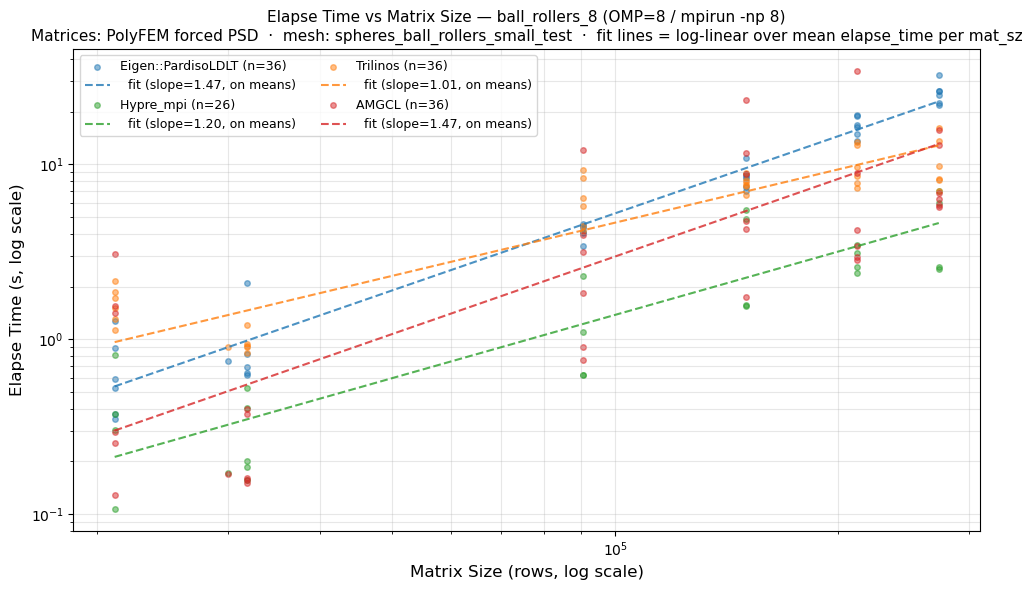

In [4]:
df8 = load_all_logs(LOG_DIR)
print(f"ball_rollers_8: {len(df8)} entries")
print(df8.groupby('solver').agg({'mat_sz': ['min', 'max', 'count'], 'elapse_time': 'mean'}))

fig, ax = plot_time_vs_mat_sz(df8, 'Elapse Time vs Matrix Size — ball_rollers_8 (OMP=8 / mpirun -np 8)')
plt.show()

## Number of iterations vs matrix size — `ball_rollers_8`

Iterative solvers only — `Eigen::PardisoLDLT` is a direct solver and does not report `num_iterations`.

Iterative entries: 98
          mat_sz               num_iterations            
             min     max count           mean   min   max
solver                                                   
AMGCL      21102  273267    36      13.527778   3.0  55.0
Hypre_mpi  21102  273267    26      32.307692   6.0  82.0
Trilinos   21102  273267    36      42.416667  16.0  90.0


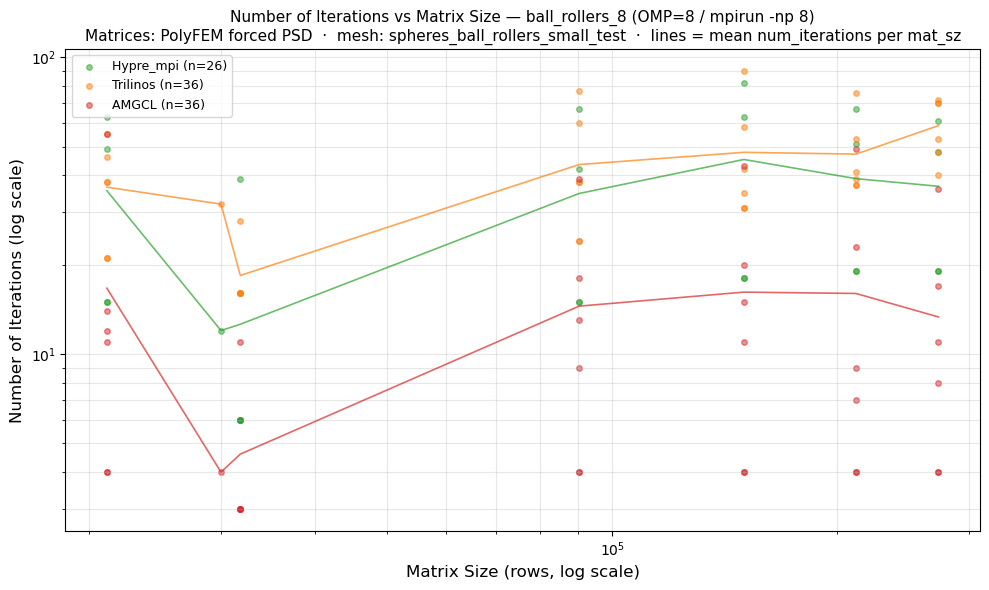

In [5]:
df8_iter = df8[df8['num_iterations'].notna() & (df8['solver'] != 'Eigen::PardisoLDLT')]
print(f"Iterative entries: {len(df8_iter)}")
print(df8_iter.groupby('solver').agg({'mat_sz': ['min', 'max', 'count'], 'num_iterations': ['mean', 'min', 'max']}))

fig, ax = plt.subplots(figsize=(10, 6))
for solver in SOLVER_PREFIXES:
    g = df8_iter[df8_iter['solver'] == solver]
    if g.empty:
        continue
    color = SOLVER_COLORS[solver]
    ax.scatter(g['mat_sz'], g['num_iterations'], s=16, alpha=0.5, color=color,
               label=f"{solver} (n={len(g)})")

    g_mean = g.groupby('mat_sz')['num_iterations'].mean().reset_index().sort_values('mat_sz')
    if len(g_mean) >= 2:
        ax.plot(g_mean['mat_sz'], g_mean['num_iterations'], '-', color=color,
                linewidth=1.2, alpha=0.7)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Matrix Size (rows, log scale)', fontsize=12)
ax.set_ylabel('Number of Iterations (log scale)', fontsize=12)
ax.set_title('Number of Iterations vs Matrix Size — ball_rollers_8 (OMP=8 / mpirun -np 8)\n'
             f'{DATA_SOURCE_NOTE}  ·  lines = mean num_iterations per mat_sz', fontsize=11)
ax.legend(fontsize=9, loc='best')
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()